In [1]:
import sys
sys.path.append('../')
import numpy as np
from ept_mark import mark
import json,os,sys
import matplotlib.pyplot as plt
from classy import Class

### Cosmology input

To compute the marked power spectrum, we require information about the cosmology.
First we define a $\texttt{CLASS}$ object:

In [2]:
params = {'output': 'mPk',
          'P_k_max_h/Mpc': 3.,
          'non linear':'halofit', 
          'z_pk': '0.0,1087',
          'A_s': 2.0830e-9,
          'n_s': 0.9649,
          'alpha_s': 0.,
          'h': 0.6736,
          'N_ur': 2.0328,
          'N_ncdm': 1,
          'tau_reio': 0.0544,
          'omega_ncdm': 0.00064420,
          'omega_b': 0.02237,
          'omega_cdm': 0.1200,
          'Omega_k': 0.}
cosmo = Class() 
cosmo.set(params) 
cosmo.compute() 

From the cosmology, we extract the necessary information ($P_{lin}$ and $f$). We also choose the desired redshift $z$ here.

In [3]:
# these are kmin, kmax, and Nk for plin
kmin = 5e-4
kmax = 1.
Nk = 500
h = cosmo.pars['h']
z= 1.1
k = np.geomspace(kmin,kmax,Nk) # [h/Mpc]
plin = np.array([cosmo.pk_cb_lin(kk*h,z)*h**3. for kk in k]) 
f = cosmo.scale_independent_growth_factor_f(z)

### Computing the marked power spectrum

With the cosmology in hand, we are set to compute the marked spectrum. Refer to Ebina+24 (https://arxiv.org/abs/2409.17133) for details.

We start by creating a $\texttt{mark}$ object, which takes the default mark $m$ and smoothing scale $R$ as inputs, in addition to $P_{lin}$. 

The mark $m$ is defined using its expansion coefficients \{$C_n$\} with respect to the smoothed overdensity field $\delta_{g,R}$ with smoothing radius $R$ (Eqn 2.3 of Ebina+24)
\begin{equation}
   m = \sum_n C_n \delta_{g,R}^n(x)
\end{equation}

Note that the dependency on mark is not used until the computed "tables" are combined for the full spectrum; i.e. there is no need to recompute the tables for a new mark. 
A new computation *is* needed when the smoothing radius is changed, however.

In [4]:
# the expansion coefficients of the mark
# these will not be called until compute_power
Cn = [1.,-1.,0,0]
# the smoothing radius of the smoothed density field used for the mark
Rcut = 30 # Mpc/h

# the directory and name of the object can be defined
# this will only be used when the numerical integrals are saved with write=True below
testdir = './'
temp_mark = mark(k,plin,nk=200,Cn=Cn,R=Rcut,name='example',N=2000,basedir=testdir)

Using the smoothing scale $R$ and cosmology information, compute contributions for each higher-point term in a "table". This is the longest computation.

These tables are independent of bias and choice of mark ($C_n$)

In [5]:
# compute contributions for each higher point term in bias and mark basis
temp_mark.compute_tables(f,write=False)
# the lengthy part of the computation can be saved into a json file with write=True

no integral13... computing
no integral13_unity... computing
no integral22_W... computing


Once the tables are computed, it is only a matter of specifying the nuisance parameters (bias, counterterms, stochastic terms) and mark ($C_n$) in order to get the marked power spectrum $M(k)$

The set of bias parameters are longer than for a one-loop power spectrum.

First we have the typical one-loop power spectrum nuisance parameters: 
- $b_1$, $b_2$, $b_s$, $b_3$ (biases), $\alpha_0$, $\alpha_2$, $\alpha_4$, $\alpha_6$ (counterterms), $N$, $N_2$, $N_4$ (stochastic terms)

- $b_3$ is a third-order bias term that combines several degenerate third-order contributions and is typically set to $0$ for power spectrum computations. Since this only appears in the power spectrum dependence of the marked spectrum, we can treat it similarly

- $\alpha_4$ and $\alpha_6$ are counterterms that contribute $\propto\mu^4$ and $\mu^6$ to the power spectrum. When constraining only the monopole and quadrupole, these are degenerate with $\alpha_0$ and $\alpha_2$, and thus can be set to $0$

and tree-level bispectrum nuisance parameters (Eqn A.3 of Ebina+24):
- $B_{\rm shot}$, $B_0$

and stochastic contributions (Eqn 2.26 of Ebina+24):
- $N_{m,2}^{(0)}$, $N_{m,2}^{(2)}$

and higher loop-order large-scale corrections (Eqn 3.6 of Ebina+24):
- $\Delta b$, $\Delta f$

In [6]:
# define nuisance parameters: 
pars = [1.2, -1.5, 0, 0, # b1, b2, bs, b3
       -3,3,0,0, # alpha0, alpha2, alpha4, alpha6
       3000,0,0, # sn, sn2, sn4
       1,1, # bshot, b0
       0,0, # nm0, nm2
       0,0] # db, df

# use the computed tables to compute power for specific mark and nuisance paramters 

# if unspecified, temp_mark will call its registered mark (Cn)
Mk1 = temp_mark.compute_power(pars,f)
# you can also specify
# specifying is required if you want the cross spectrum between two different marked fields
Mk2 = temp_mark.compute_power(pars,f,Cn=[1,0,0,0], Cn2=[1,-1,0,0])

In [7]:
# the marked power spectrum will be outputted with shape (ell, nk)
# the corresponding kvector can be accessed with temp_mark.kv
print(Mk1.shape, temp_mark.kv.shape)

(3, 200) (200,)


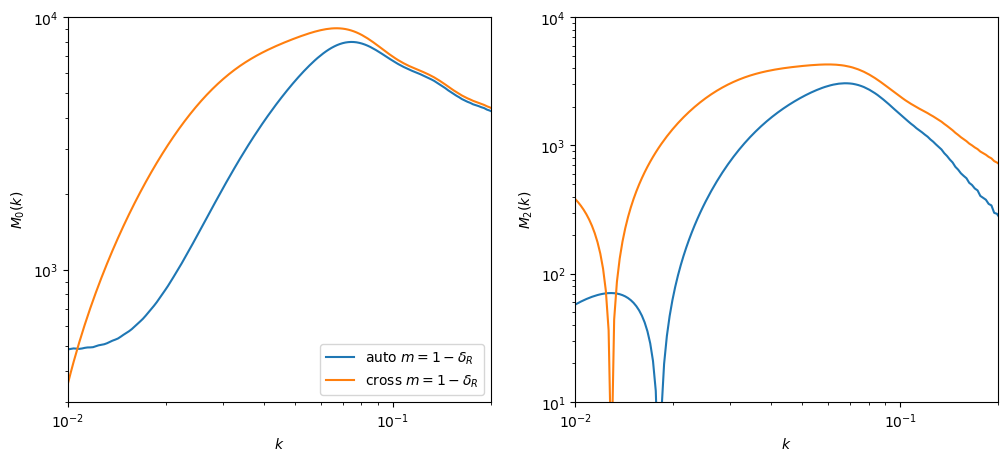

In [8]:
fig,axs = plt.subplots(1,2,figsize=(12,5))
ax = axs[0]
ax.plot(temp_mark.kv,Mk1[0],label=r'auto $m=1-\delta_R$')
ax.plot(temp_mark.kv,Mk2[0],label=r'cross $m=1-\delta_R$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(.01,.2); ax.set_ylim(3e2,1e4)
ax.set_ylabel(r'$M_0(k)$')
ax.set_xlabel(r'$k$')
ax.legend(loc='lower right')

ax = axs[1]
ax.plot(temp_mark.kv,np.abs(Mk1[1]))
ax.plot(temp_mark.kv,np.abs(Mk2[1]))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(.01,.2); ax.set_ylim(.1e2,1e4)
ax.set_ylabel(r'$M_2(k)$')
ax.set_xlabel(r'$k$')

fig.show()